# Time Series Analysis

## Libraries used

In [109]:
# imports
!pip install wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from collections import Counter

# Reproducibility
RANDOM_STATE = 10
np.random.seed(RANDOM_STATE)


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
Exception ignored while finalizing file <_io.FileIO name=7 mode='rb' closefd=True>:
Traceback (most recent call last):
  File "C:\Users\Usuario\AppData\Roaming\Python\Python314\site-packages\IPython\utils\_process_win32.py", line 138, in system
    res = process_handler(cmd, _system_body)
Exception ignored while finalizing file <_io.FileIO name=5 mode='wb' closefd=True>:
Traceback (most recent call last):
  File "C:\Users\Usuario\AppData\Roaming\Python\Python314\site-packages\IPython\utils\_process_win32.py", line 138, in system
    res = process_handler(cmd, _system_body)
Exception ignored while finalizing file <_io.FileIO name=6 mode='rb' closefd=True>:
Traceback (most recent call last):
  File "C:\Users\Usuario\AppData\Roaming\Python\Python314\site-packages\IPython\utils\_process_win32.py", line 138, in system
    res = process_handler(cmd, _system_body)


## Task 1: Data Loading & Exploration (Víctor)

In [110]:
# display options
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')

# the 14 records selected by the assignment
RECORDS = ['100', '101', '105', '106', '108', '109', '111',
           '112', '115', '117', '119', '201', '213', '219']
# 3-class scheme
LABEL_MAP = {
    # N — Normal / bundle branch
    'N': 'N', '.': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    # S — Supraventricular ectopic
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    # V — Ventricular ectopic
    'V': 'V', 'E': 'V',
}

# colours for each class
CLASS_COLORS = {'N': '#2ca02c', 'S': '#1f77b4', 'V': '#d62728'}

In [111]:
# load the 14 records
records_data = {}
for rid in RECORDS:
    rec = wfdb.rdrecord(rid, pn_dir='mitdb')
    ann = wfdb.rdann(rid, 'atr', pn_dir='mitdb')
    records_data[rid] = {
        'signal':  rec.p_signal[:, 0],
        'fs':      rec.fs,
        'samples': np.asarray(ann.sample),
        'symbols': np.asarray(ann.symbol),
    }

FS = records_data['100']['fs']
n_total_annotations = sum(d['samples'].size for d in records_data.values())

print(f'Records loaded         : {len(records_data)}')
print(f'Sampling rate          : {FS} Hz')
print(f'Signal shape (record 100): {records_data["100"]["signal"].shape}')
print(f'Total raw annotations  : {n_total_annotations:,}')

Records loaded         : 14
Sampling rate          : 360 Hz
Signal shape (record 100): (650000,)
Total raw annotations  : 31,219


The 14 records were loaded without any problem at 360Hz, with 30 minutes of every signal (650000 samples = 30min x 60s x 360Hz). We have 31.219 raw annotations before applying AAMI.

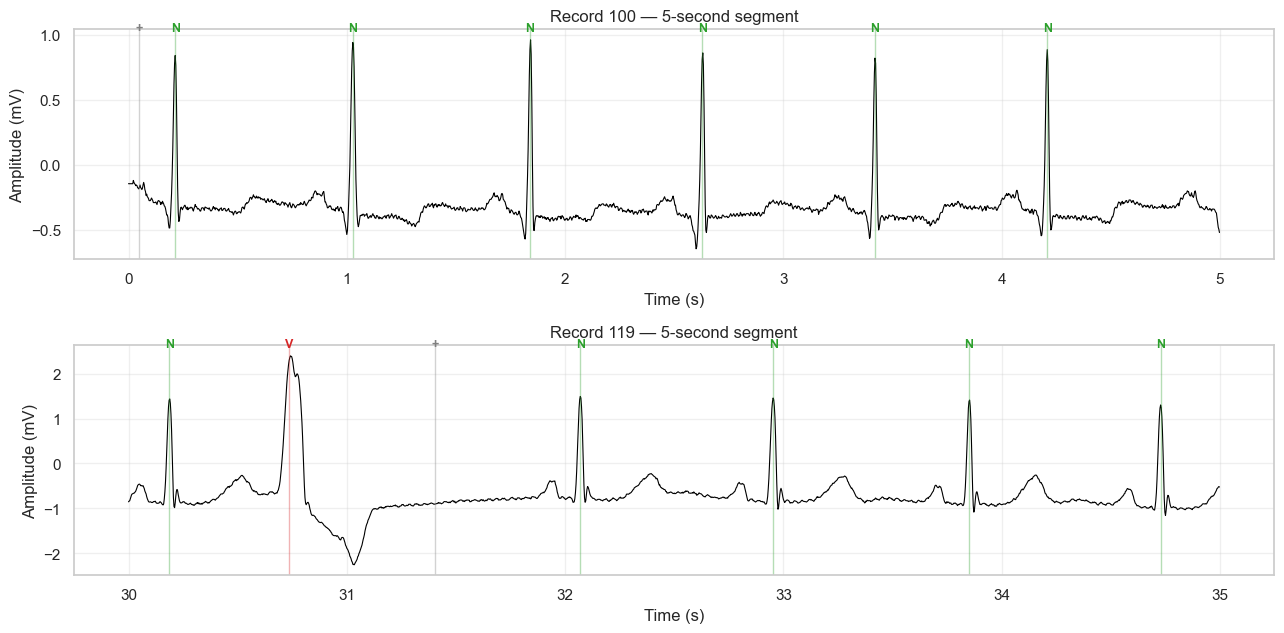

In [112]:
# ECG signals plots
def plot_ecg_segment(record_id, start_seconds, duration_seconds, ax):
    d = records_data[record_id]
    fs = d['fs']
    start = int(start_seconds * fs)
    end   = int((start_seconds + duration_seconds) * fs)
    signal = d['signal'][start:end]
    t = np.arange(start, end) / fs

    ax.plot(t, signal, color='black', lw=0.8)

    in_seg = (d['samples'] >= start) & (d['samples'] < end)
    for s, sym in zip(d['samples'][in_seg], d['symbols'][in_seg]):
        aami = LABEL_MAP.get(sym, '?')
        color = CLASS_COLORS.get(aami, 'gray')
        ax.axvline(s / fs, color=color, alpha=0.35, lw=1)
        ax.text(s / fs, signal.max() * 1.05, sym, color=color,
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude (mV)')
    ax.set_title(f'Record {record_id} — {duration_seconds}-second segment')
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(2, 1, figsize=(13, 6.5))
plot_ecg_segment('100', start_seconds=0,  duration_seconds=5, ax=axes[0])
plot_ecg_segment('119', start_seconds=30, duration_seconds=5, ax=axes[1])
plt.tight_layout()
plt.show()

Record 100 shows regular sinus rhythm (six N beats evenly spaced at ~0.8 s with consistent narrow-QRS morphology).

Record 119 highlights the contrast the classifier must learn: a single V beat (red) appears between normal beats, with markedly wider QRS, nearly double the amplitude and a clearly distinct shape.

The grey + markers correspond to rhythm-change annotations, which are not part of the AAMI scheme and will be discarded in the next step.

Total annotations : 31,219
Kept (N/S/V)      : 30,162
Discarded         : 1,057

Discarded symbols (top 10):
symbol
F    369
+    252
~    196
x    181
|     48
Q      7
"      4
      count  proportion
aami                   
N     28412      0.9420
S       206      0.0068
V      1544      0.0512


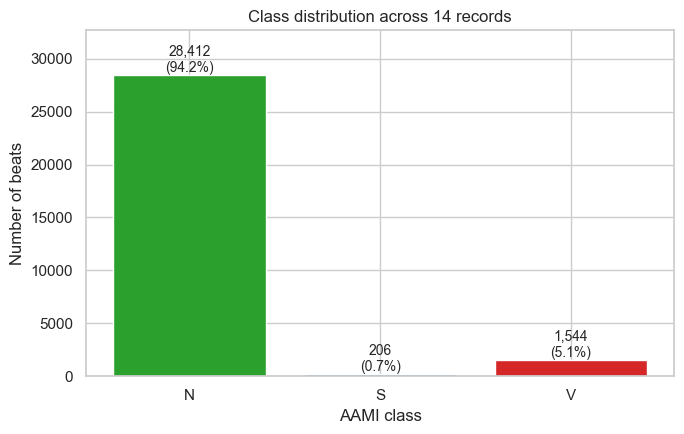

In [113]:
# AAMI label mapping and class distribution
rows = []
for rid, d in records_data.items():
    for s, sym in zip(d['samples'], d['symbols']):
        rows.append({'record_id': rid, 'sample': s, 'symbol': sym,
                     'aami': LABEL_MAP.get(sym, None)})

annotations_df = pd.DataFrame(rows)
beats_df = annotations_df.dropna(subset=['aami']).reset_index(drop=True)

n_kept     = len(beats_df)
n_discard  = len(annotations_df) - n_kept

print(f'Total annotations : {len(annotations_df):,}')
print(f'Kept (N/S/V)      : {n_kept:,}')
print(f'Discarded         : {n_discard:,}')
print('\nDiscarded symbols (top 10):')
print(annotations_df[annotations_df['aami'].isna()]['symbol']
      .value_counts().head(10).to_string())

class_counts = beats_df['aami'].value_counts().reindex(['N', 'S', 'V'])
class_props  = beats_df['aami'].value_counts(normalize=True).reindex(['N', 'S', 'V'])

balance = pd.DataFrame({'count': class_counts, 'proportion': class_props.round(4)})
print(balance)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(class_counts.index, class_counts.values,
              color=[CLASS_COLORS[c] for c in class_counts.index])
for b, v in zip(bars, class_counts.values):
    ax.text(b.get_x() + b.get_width()/2, v,
            f'{v:,}\n({v/class_counts.sum()*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Number of beats')
ax.set_xlabel('AAMI class')
ax.set_title('Class distribution across 14 records')
ax.set_ylim(0, class_counts.max() * 1.15)
plt.tight_layout()
plt.show()

After applying the AAMI mapping, 30,162 beats are retained (96.6% of the 31,219 raw annotations) and 1,057 are discarded — mostly fusion beats (F, n=369), rhythm-change markers (52) and noise annotations (196).
The class distribution is severely imbalanced: 94.2% N, 5.1% V and only 0.7% (just 206 beats across all 14 records). This confirms that macro F1 is the only sensible headline metric.

In [114]:
#heatmap(need features) will be executed at the end of task 2

def plot_feature_correlation(features_df):
    available = [c for c in FEATURE_NAMES if c in features_df.columns]
    corr = features_df[available].corr()

    fig, ax = plt.subplots(figsize=(8, 6.5))
    sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
                annot=True, fmt='.2f', square=True, linewidths=0.4,
                cbar_kws={'shrink': 0.75}, ax=ax)
    ax.set_title('Pearson correlation — 8 engineered features')
    plt.tight_layout()
    plt.show()

    # Top correlated pairs
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    pairs = (corr.where(mask).stack()
                 .rename('corr').reset_index()
                 .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'}))
    pairs['abs_corr'] = pairs['corr'].abs()
    top = pairs.sort_values('abs_corr', ascending=False).head(5).reset_index(drop=True)
    print('Top 5 correlated feature pairs:')
    print(top.round(3).to_string(index=False))

## Task 2: Preprocessing & Feature Analysis (Ana)

### 2.1 AAMI Label Mapping and Beat Filtering

The original heartbeat annotations are mapped into the selected AAMI classes. Beats that do not belong to the target classes are removed so that the dataset focuses only on the categories used for classification.

In [115]:
# AAMI label mapping and class distribution

discarded_symbols = []
discarded_indices = []

for rid, d in records_data.items():

    # map symbols to AAMI classes
    aami = [LABEL_MAP.get(sym, None) for sym in d['symbols']]

    # valid beats mask
    valid_mask = np.array([lbl is not None for lbl in aami])

    # save discarded info BEFORE filtering
    discarded_symbols.extend(d['symbols'][~valid_mask])

    discarded_indices.extend(
        [(rid, idx) for idx in np.where(~valid_mask)[0]]
    )

    # keep only valid beats
    records_data[rid]['samples'] = d['samples'][valid_mask]
    records_data[rid]['symbols'] = d['symbols'][valid_mask]
    records_data[rid]['aami'] = np.array(aami)[valid_mask]

print(f'Total annotations : {len(discarded_indices) + sum(len(d["samples"]) for d in records_data.values()):,}')
print(f'Kept (N/S/V)      : {sum(len(d["samples"]) for d in records_data.values()):,}')
print(f'Discarded         : {len(discarded_indices):,}')


Total annotations : 31,219
Kept (N/S/V)      : 30,162
Discarded         : 1,057


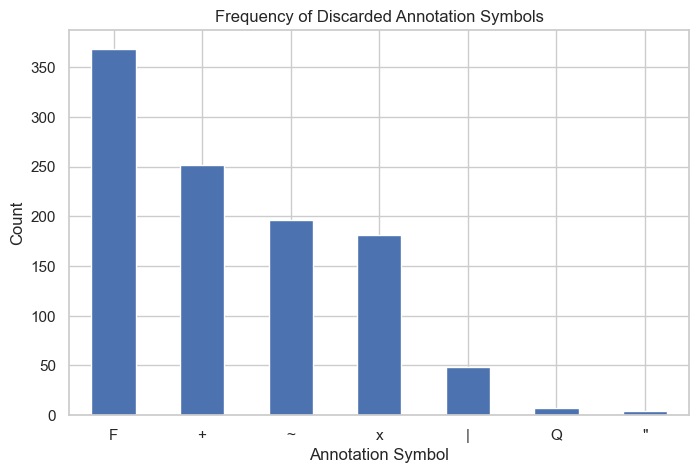

In [116]:
# frequency of discarded symbols
discarded_counts = pd.Series(discarded_symbols).value_counts()

# bar chart
plt.figure(figsize=(8, 5))
discarded_counts.plot(kind='bar')

plt.title('Frequency of Discarded Annotation Symbols')
plt.xlabel('Annotation Symbol')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

### 2.2 Feature Extraction: 8 Features per Beat

For each heartbeat, eight descriptive features are extracted from the ECG signal.

In [117]:
FEATURE_NAMES = ['RR_current', 'RR_prev', 'RR_ratio', 'RR_local_mean', 'R_amplitude', 'QRS_duration', 'QRS_energy', 'ST_mean']

In [118]:
min_len = min(len(d['samples']) for d in records_data.values())
print(min_len)

1535


In [119]:
# Function to compute the 'QRS_duration' using a threshold-based method around the R-peak
def find_qrs_duration(signal, r_idx, R_amplitude):

    # QRS duration estimates the width of the ventricular depolarization complex
    # using a threshold-based method around the R-peak.

    threshold = 0.5 * R_amplitude  # 50% of peak amplitude (adaptive threshold)

    # LEFT CROSSING: search backwards from R-peak until signal drops below threshold
    left_cross = None
    for i in range(r_idx, -1, -1):
        if signal[i] < threshold:
            left_cross = i
            break

    # RIGHT CROSSING: search forward from R-peak until signal drops below threshold
    right_cross = None
    for i in range(r_idx, len(signal)):
        if signal[i] < threshold:
            right_cross = i
            break

    # If boundaries are not found, return NaN (robust handling of edge cases/noise)
    if left_cross is None or right_cross is None:
        return np.nan

    # QRS duration in samples (can be converted to ms if needed)
    return right_cross - left_cross

In [123]:
import warnings
warnings.simplefilter("error")
record_features = []

# Iterate over each ECG record independently to preserve patient-level structure
for rid, d in records_data.items():

    signal = d['signal']
    fs = d['fs']
    samples = d['samples']
    labels = d['aami']

    # Each sample corresponds to an R-peak (one heartbeat)
    for i in range(len(samples)):

        r_idx = samples[i]

        # ---------------- RR INTERVAL FEATURES ----------------
        # RR features capture temporal variability between consecutive heartbeats

        if i >= 4:

            # Current and previous RR intervals (beat-to-beat timing)
            rr_current = (samples[i] - samples[i-1]) / fs * 1000
            rr_prev = (samples[i-1] - samples[i-2]) / fs * 1000

            # Local rhythm baseline computed over last 5 beats (i-4 to i)
            rr_local_mean = np.mean([
                (samples[i-3] - samples[i-4]),
                (samples[i-2] - samples[i-3]),
                (samples[i-1] - samples[i-2]),
                (samples[i]   - samples[i-1])
            ]) / fs * 1000

            # Relative deviation from local rhythm
            rr_ratio = rr_current / rr_local_mean if rr_local_mean != 0 else 0

        else:
            # Edge case: first beats (insufficient history)
            # Approximate using first 5 RR intervals of the record
            rr_local_mean = np.mean([
                (samples[j] - samples[j-1]) / fs * 1000
                for j in range(1, 5)
            ])

            rr_current = rr_local_mean
            rr_prev = rr_local_mean
            rr_ratio = 1.0

        # ---------------- MORPHOLOGICAL FEATURES ----------------
        # Extracted around the R-peak to capture beat morphology

        # Local R amplitude (QRS peak intensity)
        r_amplitude = np.mean(signal[r_idx-5:r_idx+6])

        # QRS duration: width of ventricular depolarization
        qrs_duration = find_qrs_duration(signal, r_idx, r_amplitude)

        # QRS energy: total electrical activity in QRS complex
        qrs_energy = np.sum(signal[r_idx-20:r_idx+21] ** 2)

        # ST segment: early repolarization phase after QRS complex
        if r_idx + 40 < len(signal):
            st_mean = np.mean(signal[r_idx+40 : min(r_idx+120, len(signal))])
        else:
            st_mean = np.nan

        # ---------------- STORE FEATURE VECTOR ----------------
        record_features.append({
            'record_id': rid,        # used for traceability (not model input)
            'sample': r_idx,         # R-peak position in signal
            'RR_current': rr_current,
            'RR_prev': rr_prev,
            'RR_ratio': rr_ratio,
            'RR_local_mean': rr_local_mean,
            'R_amplitude': r_amplitude,
            'QRS_duration': qrs_duration,
            'QRS_energy': qrs_energy,
            'ST_mean': st_mean,
            'label': labels[i]
        })

# Final feature matrix (one row per heartbeat)
features_df = pd.DataFrame(record_features)

In [124]:
for col in FEATURE_NAMES:
    n_missing = features_df[col].isna().sum()
    print(f'Feature "{col}" has {n_missing} missing values.')

Feature "RR_current" has 0 missing values.
Feature "RR_prev" has 0 missing values.
Feature "RR_ratio" has 0 missing values.
Feature "RR_local_mean" has 0 missing values.
Feature "R_amplitude" has 0 missing values.
Feature "QRS_duration" has 0 missing values.
Feature "QRS_energy" has 0 missing values.
Feature "ST_mean" has 2 missing values.


In [125]:
features_df = features_df.dropna()

#### First-beat edge case handling

The first beats in each ECG record do not have sufficient previous R-peak information to compute RR-based features (RR_current, RR_prev, and RR_local_mean).

To handle this boundary condition, these features were approximated using the mean RR interval of the first five available beats in the record.

This approach provides a stable baseline estimate of the heart rhythm and avoids introducing missing values or artificial bias at the beginning of each sequence.

Additionally, for the ST_mean feature, the extraction window was right-truncated at the signal boundary (min(r_idx + 120, len(signal))) to avoid out-of-bounds indexing. If the window exceeded the signal length, the mean was computed using the available samples only.

Two beats produced missing values for ST_mean because they were located near the end of the ECG signal and did not contain enough subsequent samples (+40) to define the ST-segment window. Since these represented a negligible proportion of the dataset, the corresponding beats were removed prior to training.

In [126]:
features_df.head()

,record_id,sample,RR_current,RR_prev,RR_ratio,RR_local_mean,R_amplitude,QRS_duration,QRS_energy,ST_mean,label
0,100,77,801.388889,801.388889,1.000000,801.388889,0.326364,8,6.79495,-0.343125,N
1,100,370,801.388889,801.388889,1.000000,801.388889,0.495455,8,8.95210,-0.410688,N
2,100,662,801.388889,801.388889,1.000000,801.388889,0.347727,7,9.14830,-0.394750,N
3,100,946,801.388889,801.388889,1.000000,801.388889,0.307727,7,9.52190,-0.365687,N
4,100,1231,791.666667,788.888889,0.987868,801.388889,0.250000,8,8.07610,-0.404250,N


In [127]:
features_df.shape

(30160, 11)

### 2.3 Correlation Analysis (task 1)

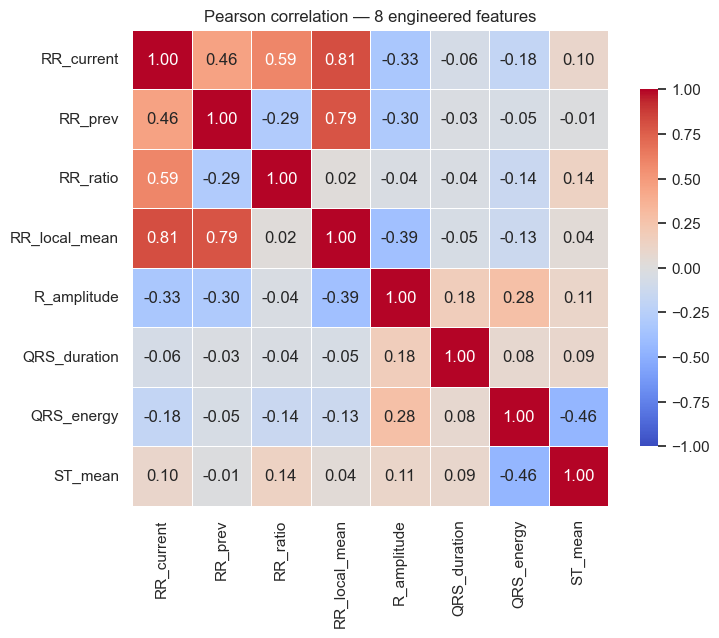

Top 5 correlated feature pairs:
 feature_1     feature_2   corr  abs_corr
RR_current RR_local_mean  0.813     0.813
   RR_prev RR_local_mean  0.791     0.791
RR_current      RR_ratio  0.588     0.588
RR_current       RR_prev  0.460     0.460
QRS_energy       ST_mean -0.459     0.459


In [128]:
#heatmap (task 1)
plot_feature_correlation(features_df)

### 2.4 Train-Test Split

The feature dataset is divided into training and test sets using stratified sampling. This preserves the class distribution in both sets, which is especially important because the heartbeat classes are imbalanced.

In [129]:

from sklearn.model_selection import train_test_split

X = features_df.drop(columns=['record_id', 'sample', 'label'])
y = features_df['label']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Class distribution summary
def class_summary(y):
    df = y.value_counts().to_frame('beat count')
    df['percentage'] = y.value_counts(normalize=True) * 100
    return df

print("Train:")
print(class_summary(y_train))

print("\nTest:")
print(class_summary(y_test))

Train:
       beat count  percentage
label                        
N           22728   94.197613
V            1235    5.118534
S             165    0.683853

Test:
       beat count  percentage
label                        
N            5682   94.197613
V             309    5.122679
S              41    0.679708


Stratified split ensures that the strong class imbalance of the dataset is preserved in both training and test sets.

### 2.5 Feature Scaling

The features (all are numerical) are standardized using statistics learned from the training set only. Scaling ensures that all features contribute comparably and prevents larger-valued variables from dominating the models.

In [130]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to df
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_scaled_df = X_train_scaled_df.reset_index(drop=True)
X_test_scaled_df = X_test_scaled_df.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

### 2.6 Sliding Window Construction for RNN and LSTM

Sequential windows of consecutive heartbeats are created for the recurrent models. Each window provides temporal context, allowing the RNN and LSTM to learn patterns across multiple beats instead of treating each beat independently. For each beat at position i ≥ 10, a sample is created consisting of the feature vectors for beats i−9 through i (shape: 10 × 8) with label equal to the class of beat i.

In [131]:
X_train_windows = [
    X_train_scaled_df.iloc[i-9:i+1].values
    for i in range(9, len(X_train))
]

y_train_windows = [y_train.iloc[i] for i in range(9, len(y_train))]

X_test_windows = [
    X_test_scaled_df.iloc[i-9:i+1].values
    for i in range(9, len(X_test))
]

y_test_windows = [y_test.iloc[i] for i in range(9, len(y_test))]

## Task 3: RNN - Sequence Classification (---name of the owner---)

### Task 3.5: Extension - LSTM (---name of the owner---)

## Task 4: Model Comparison & Evaluation (---name of the owner---)